### Exercise 5

In [ ]:
from collections import defaultdict
import numpy as np
import gymnasium as gym
import skyscraper
from collections import defaultdict
import random
import os
import matplotlib.pyplot as plt
import time

In [2]:
def build_model_from_flight_data(path, goal=(14,54), one_indexed=True):
    """
    Returns:
      P_hat: dict mapping (s,a) -> dict of s' -> prob
      R_hat: dict mapping (s,a,s') -> expected reward 
      R_sa : dict mapping (s,a) -> expected reward
      N_sa : counts for (s,a)
      terminals: set of terminal states (goal only here)
    """
    # Counts
    N_sas = defaultdict(int)     # (s,a,s') -> count
    N_sa  = defaultdict(int)     # (s,a) -> count
    sumR_sas = defaultdict(float) # (s,a,s') -> sum rewards
    sumR_sa  = defaultdict(float) # (s,a) -> sum rewards

    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Try to parse robustly: accepts commas, spaces, parentheses
            cleaned = line.replace("(", "").replace(")", "").replace(",", " ")
            parts = cleaned.split()

            i, j, a, r, ip, jp = parts[:6]
            i, j, a, r, ip, jp = int(i), int(j), int(a), float(r), int(ip), int(jp)

            if one_indexed:
                i -= 1; j -= 1; ip -= 1; jp -= 1

            s  = (i, j)
            sp = (ip, jp)

            N_sa[(s,a)] += 1
            N_sas[(s,a,sp)] += 1
            sumR_sa[(s,a)] += r
            sumR_sas[(s,a,sp)] += r

    # Build P_hat
    P_hat = {}
    for (s,a), n in N_sa.items():
        next_dict = {}
        # collect all s' seen for this (s,a)
        for (ss,aa,sp), c in N_sas.items():
            if ss == s and aa == a:
                next_dict[sp] = c / n
        P_hat[(s,a)] = next_dict

    # Reward models
    R_hat = {}
    for (s,a,sp), c in N_sas.items():
        R_hat[(s,a,sp)] = sumR_sas[(s,a,sp)] / c

    R_sa = { (s,a): (sumR_sa[(s,a)] / n) for (s,a), n in N_sa.items() }

    terminals = {goal}
    return P_hat, R_hat, R_sa, N_sa, terminals

Task 2
It learns an (approximately) optimal policy by mixing:

- Direct RL updates from real interaction with the environment
- Planning updates from a learned model M (built online from the same experience)

In [3]:
H, W = 32, 64
A = 2
START = (13, 5)
GOAL = (14, 54)

def obs_to_state(obs):
    i, j = obs["agent"]["pos"]
    return (int(i), int(j))

def epsilon_greedy(Q, s, eps):
    if random.random() < eps:
        return random.randrange(A)
    return int(np.argmax(Q[s[0], s[1], :]))

def detect_crash_from_transition(s, sp, r, terminated, start_state=START):
    return (not terminated) and (r == 0) and (sp == start_state) and (s != start_state)

class EmpiricalModel:
    def __init__(self):
        self.next_counts = defaultdict(int)   # (s,a,sp) -> count
        self.r_sums = defaultdict(float)      # (s,a,sp) -> sum reward
        self.terminal_counts = defaultdict(int)  # (s,a,sp) -> times sp was terminal
        self.sa_set = set()

    def update(self, s, a, r, sp, terminal):
        self.sa_set.add((s, a))
        self.next_counts[(s, a, sp)] += 1
        self.r_sums[(s, a, sp)] += r
        if terminal:
            self.terminal_counts[(s, a, sp)] += 1

    def sample_sa(self):
        return random.choice(tuple(self.sa_set))

    def sample(self, s, a):
        candidates = []
        weights = []
        for (ss, aa, sp), c in self.next_counts.items():
            if ss == s and aa == a:
                candidates.append(sp)
                weights.append(c)

        if not candidates:
            return s, 0.0, False

        sp = random.choices(candidates, weights=weights, k=1)[0]
        c = self.next_counts[(s, a, sp)]
        r = self.r_sums[(s, a, sp)] / c

        term_count = self.terminal_counts[(s, a, sp)]
        terminal_prob = term_count / c
        terminal = (random.random() < terminal_prob)

        return sp, r, terminal

The previously collected experience is used to learn a model of the environment, which is then used to generate simulated experience for planning updates. This allows the agent to improve its policy more efficiently by leveraging both real and simulated interactions with the environment.

In [4]:
def preload_model_from_file(model, filepath):
    with open(filepath, "r") as f:
        for line in f:
            i, j, a_file, r, ip, jp = map(int, line.split())

            # convert 1-indexed file -> 0-indexed env
            s = (i - 1, j - 1)
            sp = (ip - 1, jp - 1)

            # convert file action 1/2 -> env action 0/1
            a = a_file - 1

            # infer terminal from reward or reset-to-start pattern
            terminated = (sp == GOAL and r == 1)
            crashed = (sp == START and s != START and r == 0)
            terminal = terminated or crashed

            model.update(s, a, float(r), sp, terminal)

Method - train the Dyna-Q agent for 1000 episodes and plot the trajectory of the agent in the environment.

In [5]:
def train_dyna_q(
    env,
    model = None,
    episodes=3000,
    alpha=0.15,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=2000,
    planning_steps=30,
    max_steps_per_episode=600
):
    if model is None:
        model = EmpiricalModel()
   
    Q = np.zeros((H, W, A), dtype=np.float32)
    returns = []

    for ep in range(episodes):
        obs, _ = env.reset()
        s = obs_to_state(obs)
        G = 0.0

        frac = min(1.0, ep / max(1, eps_decay_steps))
        eps = eps_start + frac * (eps_end - eps_start)

        for _ in range(max_steps_per_episode):
            a = epsilon_greedy(Q, s, eps)

            obs2, r, terminated, truncated, _ = env.step(a)
            sp = obs_to_state(obs2)

            crashed = detect_crash_from_transition(s, sp, r, terminated)
            terminal = terminated or crashed

            # real update
            target = r if terminal else r + gamma * np.max(Q[sp[0], sp[1], :])
            Q[s[0], s[1], a] += alpha * (target - Q[s[0], s[1], a])

            # model update
            model.update(s, a, float(r), sp, terminal)

            # planning
            if model.sa_set:
                for _ in range(planning_steps):
                    ss, aa = model.sample_sa()
                    spp, rr, termp = model.sample(ss, aa)

                    target_p = rr if termp else rr + gamma * np.max(Q[spp[0], spp[1], :])
                    Q[ss[0], ss[1], aa] += alpha * (target_p - Q[ss[0], ss[1], aa])

            G += r
            s = sp

            if terminal or truncated:
                break

        returns.append(G)

        if (ep + 1) % 200 == 0:
            print(f"Episode {ep+1}, avg return (last 200): {np.mean(returns[-200:]):.3f}")

    policy = np.argmax(Q, axis=2)
    return Q, policy, returns

plot trajectory

In [6]:
def rollout_greedy_trajectory(env, Q, max_steps=300):
    obs, _ = env.reset()
    s = obs_to_state(obs)

    trajectory = [s]
    crashed = False
    reached_goal = False

    for _ in range(max_steps):
        a = int(np.argmax(Q[s[0], s[1], :]))
        obs2, r, terminated, truncated, _ = env.step(a)
        sp = obs_to_state(obs2)

        step_crashed = detect_crash_from_transition(s, sp, r, terminated)

        trajectory.append(sp)

        if step_crashed:
            crashed = True
            break
        if terminated:
            reached_goal = True
            break
        if truncated:
            break

        s = sp

    return trajectory, reached_goal, crashed

In [7]:
def plot_trajectory_on_map(trajectory, title="Learned greedy trajectory"):
    skyline = np.genfromtxt(os.path.join("skyscraper", "envs", "skyline.txt"), float)

    plt.figure(figsize=(16, 6))
    plt.imshow(skyline, cmap="gray", origin="upper")

    rows = [s[0] for s in trajectory]
    cols = [s[1] for s in trajectory]

    plt.plot(cols, rows, marker="o", linewidth=2, markersize=4, label="trajectory")
    plt.scatter([START[1]], [START[0]], s=120, marker="o", label="start")
    plt.scatter([GOAL[1]], [GOAL[0]], s=120, marker="s", label="goal")

    plt.title(title)
    plt.xlabel("column j")
    plt.ylabel("row i")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

Run and call plot_trajectory() to see the trajectory of the agent. 

in skyscraper.py it has the following code in the step() function:

```
if reward > 0:
    print(observation, reward)
```

So whenever the drone reaches the goal, the environment prints: the observation, the reward:

{'agent': {'pos': array([14., 54.])}}

In [8]:
env = gym.make("skyscraper/GridWorld-v0")

Q = np.zeros((32,64,2))
model = EmpiricalModel()

# ---- preload  ----
preload_model_from_file(model, "powered_flight.txt")

Q, policy, returns = train_dyna_q(
    env,
    model=model,
    episodes=3000,
    alpha=0.15,
    gamma=0.99,
    planning_steps=30,
    max_steps_per_episode=600
)

<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
c:\Users\somme\anaconda3\envs\gymenv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be int32, actual type: int64
  logger.warn(
c:\Users\somme\anaconda3\envs\gymenv\Lib\site-pa

Episode 200, avg return (last 200): 0.000
Episode 400, avg return (last 200): 0.000
Episode 600, avg return (last 200): 0.000
Episode 800, avg return (last 200): 0.000
Episode 1000, avg return (last 200): 0.000
Episode 1200, avg return (last 200): 0.000
Episode 1400, avg return (last 200): 0.000
{'agent': {'pos': array([14., 54.])}} 1
{'agent': {'pos': array([14., 54.])}} 1
{'agent': {'pos': array([14., 54.])}} 1
{'agent': {'pos': array([14., 54.])}} 1
{'agent': {'pos': array([14., 54.])}} 1
{'agent': {'pos': array([14., 54.])}} 1
{'agent': {'pos': array([14., 54.])}} 1
{'agent': {'pos': array([14., 54.])}} 1
{'agent': {'pos': array([14., 54.])}} 1
{'agent': {'pos': array([14., 54.])}} 1
{'agent': {'pos': array([14., 54.])}} 1
Episode 1600, avg return (last 200): 0.055
{'agent': {'pos': array([14., 54.])}} 1
{'agent': {'pos': array([14., 54.])}} 1
{'agent': {'pos': array([14., 54.])}} 1
{'agent': {'pos': array([14., 54.])}} 1
{'agent': {'pos': array([14., 54.])}} 1
{'agent': {'pos': ar

{'agent': {'pos': array([14., 54.])}} 1
Reached goal: True
Crashed: False
Trajectory length: 41


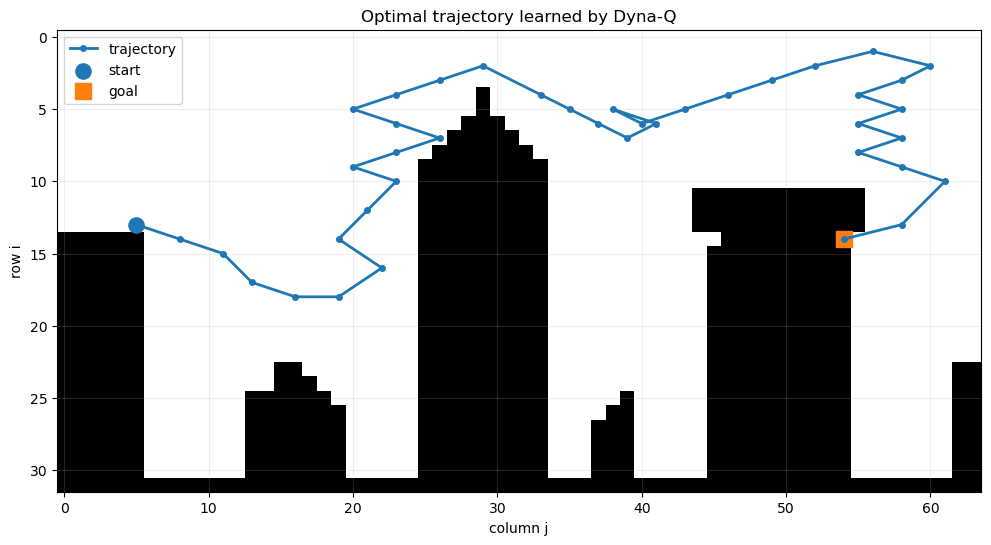

In [9]:
trajectory, reached_goal, crashed = rollout_greedy_trajectory(env, Q)

print("Reached goal:", reached_goal)
print("Crashed:", crashed)
print("Trajectory length:", len(trajectory))

plot_trajectory_on_map(
    trajectory,
    title="Optimal trajectory learned by Dyna-Q"
)

In [10]:
# Test a greedy rollout
obs, _ = env.reset()
s = obs_to_state(obs)
for _ in range(600):
    a = int(np.argmax(Q[s[0], s[1], :]))
    obs, r, terminated, truncated, info = env.step(a)
    s = obs_to_state(obs)
    if terminated:
        print("Reached goal!")
        break
env.close()

{'agent': {'pos': array([14., 54.])}} 1
Reached goal!


plot learning curve

In [11]:
def plot_learning_curve(returns, window=100):
    plt.figure(figsize=(10, 4))
    plt.plot(returns, alpha=0.4, label="episode return")

    if len(returns) >= window:
        moving_avg = np.convolve(returns, np.ones(window)/window, mode="valid")
        plt.plot(range(window - 1, len(returns)), moving_avg, linewidth=2,
                 label=f"{window}-episode moving average")

    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title("Dyna-Q learning curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

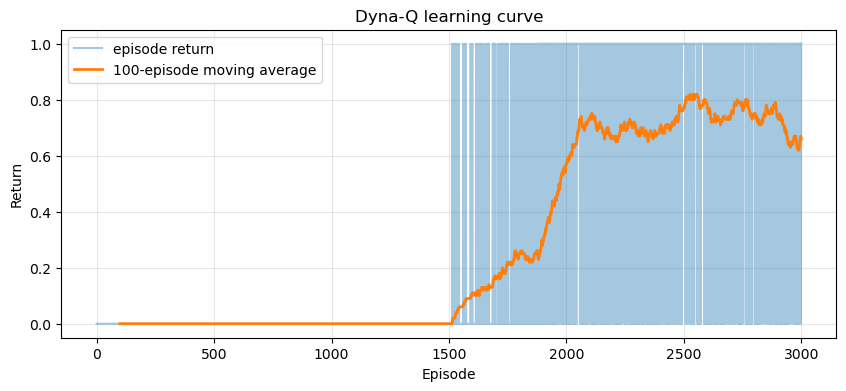

In [12]:
plot_learning_curve(returns)

Task 4:

Run Dyna changing the number of simulations run by the agent using ˆM, and compare the results.

In [ ]:
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)

def run_experiment(planning_values, seeds, episodes=2000):
    all_results = {}

    for n in planning_values:
        print(f"\nRunning planning_steps = {n}")
        seed_returns = []

        for seed in seeds:
            set_seed(seed)

            env = gym.make("skyscraper/GridWorld-v0")
            
            model = EmpiricalModel()

            # ---- preload  ----
            preload_model_from_file(model, "powered_flight.txt")
            Q, policy, returns = train_dyna_q(
                env,
                model = model,
                episodes=episodes,
                planning_steps=n,
                alpha=0.15,
                gamma=0.99,
                eps_start=1.0,
                eps_end=0.05,
                eps_decay_steps=1500,
                max_steps_per_episode=600
            )
            env.close()

            seed_returns.append(np.array(returns, dtype=float))

        all_results[n] = np.vstack(seed_returns)

    return all_results

In [20]:
def plot_comparison(all_results):
    plt.figure(figsize=(10, 5))

    for n, returns in all_results.items():
        mean_curve = returns.mean(axis=0)
        plt.plot(mean_curve, label=f"n = {n}")

    plt.xlabel("Episode")
    plt.ylabel("Average return")
    plt.title("Dyna-Q: effect of number of planning simulations")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [21]:
def moving_average(x, window=100):
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode="valid")

def plot_smoothed_comparison(all_results, window=100):
    plt.figure(figsize=(10, 5))

    for n, returns in all_results.items():
        mean_curve = returns.mean(axis=0)
        smooth = moving_average(mean_curve, window=window)
        plt.plot(range(window - 1, window - 1 + len(smooth)), smooth, label=f"n = {n}")

    plt.xlabel("Episode")
    plt.ylabel(f"Average return ({window}-episode moving average)")
    plt.title("Dyna-Q comparison for different numbers of planning simulations")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [22]:
def summarize_results(all_results):
    print("\nFinal performance summary\n")
    print(f"{'planning n':>12} | {'mean last100':>12} | {'std last100':>10}")
    print("-" * 40)

    for n, returns in all_results.items():
        last100_per_seed = returns[:, -100:].mean(axis=1)
        mean_last100 = last100_per_seed.mean()
        std_last100 = last100_per_seed.std()

        print(f"{n:12d} | {mean_last100:12.3f} | {std_last100:10.3f}")

Run Dyna changing the number of simulations run by the agent using ˆM, and compare the results.

In [ ]:
planning_values = [0, 5, 10, 30, 50, 100]
seeds = [0, 1, 2, 3, 4]

results = run_experiment(planning_values, seeds, episodes=2000)

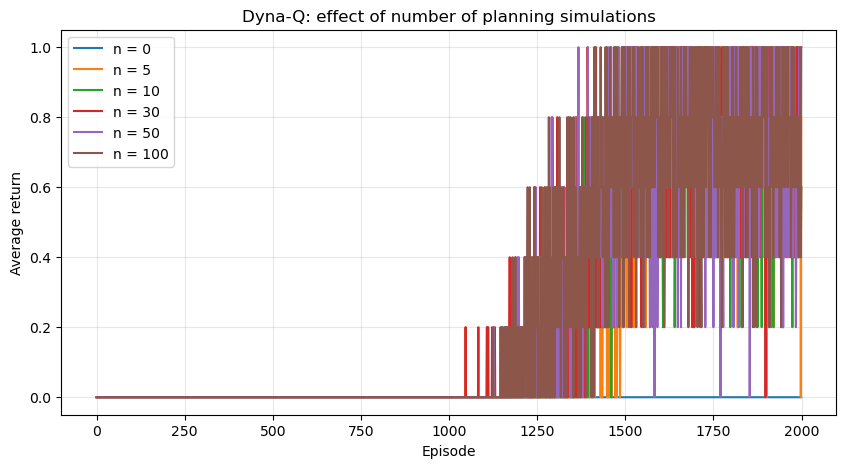

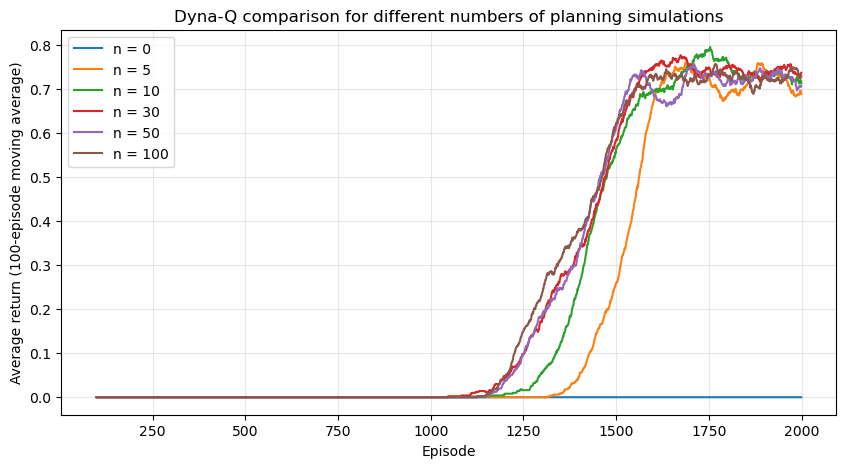


Final performance summary

  planning n | mean last100 | std last100
----------------------------------------
           0 |        0.000 |      0.000
           5 |        0.688 |      0.040
          10 |        0.712 |      0.013
          30 |        0.736 |      0.046
          50 |        0.706 |      0.045
         100 |        0.728 |      0.024


In [25]:
plot_comparison(results)
plot_smoothed_comparison(results, window=100)
summarize_results(results)

We evaluated Dyna-Q with different numbers of planning simulations per real interaction step, using n∈{0,5,10,30,50,100}. For each setting we ran multiple seeds and compared the average return over training episodes.
The results show that increasing the number of planning steps significantly improves sample efficiency. When n=0, the algorithm reduces to standard Q-learning and learns much more slowly. As 𝑛 increases, the agent is able to exploit the learned model to perform additional updates from simulated experience, leading to faster discovery of successful trajectories and earlier convergence.
Beyond a certain point, increasing 𝑛 further provides smaller gains, suggesting diminishing returns from additional planning.